# September Month Sales Analysis-Nanihaal

In [3]:
#Importing important Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
# Load dataset
df = pd.read_csv("Septmeber'25.csv")

# Convert date column
df['ORDERED_DATE'] = pd.to_datetime(df['ORDERED_DATE'])

df.head()

,Unnamed: 0,BRAND,ORDERED_DATE,CITY,AREA_NAME,STORE_ID,L1_CATEGORY,L2_CATEGORY,L3_CATEGORY,PRODUCT_NAME,VARIANT,ITEM_CODE,COMBO,COMBO_ITEM_CODE,COMBO_UNITS_SOLD,BASE_MRP,UNITS_SOLD,GMV
0,0,nanihaal,2025-09-22,Jaipur,malviya nagar,1386095,"masala, pickle and papad",whole spices,methi seeds,nanihaal sabut methi dana,100 g,629844,No,NaN,NaN,40,1,40
1,1,nanihaal,2025-09-22,Gurgaon,old gurgaon (zone 6),1389006,"masala, pickle and papad",whole spices,kalonji,nanihaal kalonji,100 g,447621,No,NaN,NaN,72,1,72
2,2,nanihaal,2025-09-22,Delhi,burari,1402053,"masala, pickle and papad",powdered spices,black pepper,nanihaal black pepper ( whole),100 g,752565,No,NaN,NaN,240,1,240
3,3,nanihaal,2025-09-22,Noida,crossing republic,1389634,"masala, pickle and papad",whole spices,tamarind,nanihaal imli ( seedless),150 g,513420,No,NaN,NaN,68,2,136
4,4,nanihaal,2025-09-22,Gurgaon,palam vihar,1384513,"masala, pickle and papad",whole spices,elaichi,nanihaal hari elaichi,20 g,451167,No,NaN,NaN,210,1,210


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Septmeber'25.csv")

df['ORDERED_DATE'] = pd.to_datetime(df['ORDERED_DATE'])

# Area wise performance
area_city_summary = df.groupby(["CITY","AREA_NAME"]).agg({
    "UNITS_SOLD":"sum",
    "GMV":"sum"
}).reset_index()

area_city_summary = area_city_summary.sort_values("GMV", ascending=False)

area_city_summary.head(20)

,CITY,AREA_NAME,UNITS_SOLD,GMV
200,Noida,crossing republic,440,43048
77,Gurgaon,jalvayu towers,389,37890
208,Noida 1,sector 50,290,28268
201,Noida,raj nagar,287,28156
206,Noida 1,noida expressway,274,27343
80,Gurgaon,old gurgaon (zone 6),250,24097
205,Noida 1,indirapuram,225,23789
83,Gurgaon,sohna road,244,22944
79,Gurgaon,new sohna road,223,21282
74,Gurgaon,dlf phase 4,192,18750


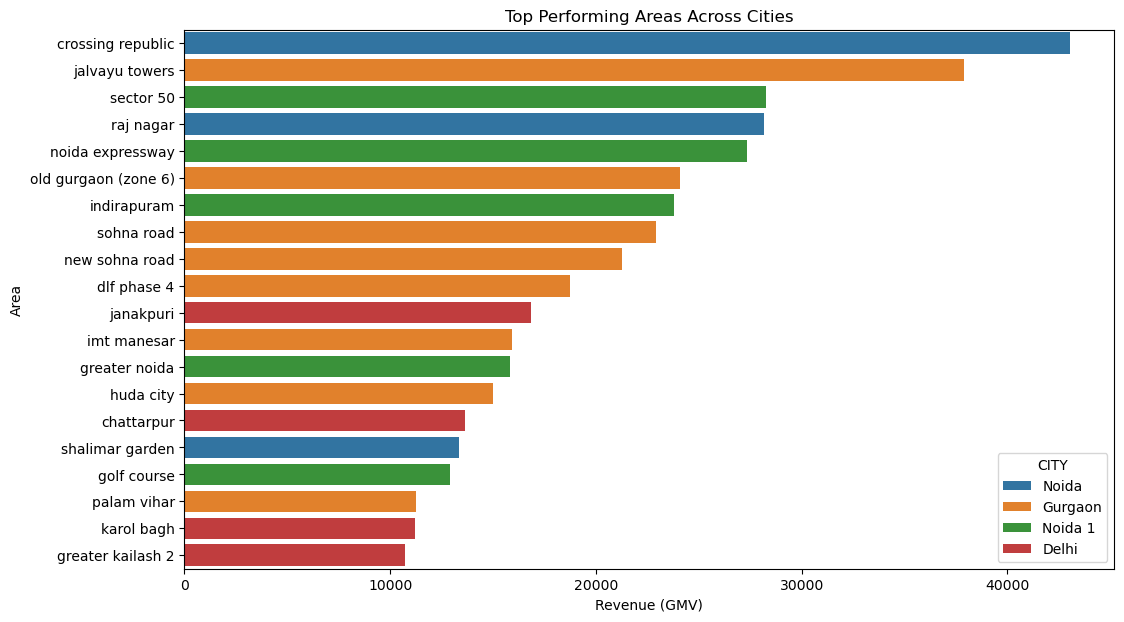

In [5]:
top_area_city = area_city_summary.head(20)

plt.figure(figsize=(12,7))

sns.barplot(
    data=top_area_city,
    x="GMV",
    y="AREA_NAME",
    hue="CITY"
)

plt.title("Top Performing Areas Across Cities")
plt.xlabel("Revenue (GMV)")
plt.ylabel("Area")

plt.show()

In [6]:
city_revenue = df.groupby("CITY")["GMV"].sum().reset_index()
city_revenue = city_revenue.sort_values("GMV", ascending=False)

city_revenue

,CITY,GMV
11,Delhi,193844
15,Gurgaon,187426
34,Noida 1,119761
33,Noida,84537
19,Jaipur,39691
24,Kolkata,38698
14,Faridabad,34092
27,Lucknow,19852
31,Mumbai,19662
4,Bhubaneswar,13922


In [10]:
# Area wise aggregation
area_table = df.groupby("AREA_NAME").agg(
    TOTAL_REVENUE = ("GMV","sum"),
    TOTAL_UNITS_SOLD = ("UNITS_SOLD","sum")
).reset_index()

In [11]:
total_revenue = area_table["TOTAL_REVENUE"].sum()

area_table["REVENUE_PERCENTAGE"] = (
    area_table["TOTAL_REVENUE"] / total_revenue
) * 100

In [12]:
area_table = area_table.sort_values(
    by="TOTAL_REVENUE",
    ascending=False
)

In [13]:
# Group data area-wise
area_table = df.groupby("AREA_NAME").agg(
    UNITS_SOLD=("UNITS_SOLD","sum"),
    TOTAL_REVENUE=("GMV","sum")
).reset_index()

# Calculate total revenue of the dataset
total_revenue = area_table["TOTAL_REVENUE"].sum()

# Calculate percentage revenue contribution
area_table["REVENUE_PERCENTAGE"] = (
    area_table["TOTAL_REVENUE"] / total_revenue
) * 100

# Round percentage values
area_table["REVENUE_PERCENTAGE"] = area_table["REVENUE_PERCENTAGE"].round(2)

# Sort areas by highest revenue
area_table = area_table.sort_values(
    by="TOTAL_REVENUE",
    ascending=False
)

# Display final table
area_table

,AREA_NAME,UNITS_SOLD,TOTAL_REVENUE,REVENUE_PERCENTAGE
50,crossing republic,440,43048,5.12
96,jalvayu towers,389,37890,4.51
203,sector 50,290,28268,3.36
189,raj nagar,287,28156,3.35
161,noida expressway,274,27343,3.25
...,...,...,...,...
69,ghatkopar vikhroli,2,60,0.01
143,matunga wadala,2,60,0.01
17,bbd,1,30,0.00
117,kothrud,1,30,0.00


In [14]:
# Define NCR cities
ncr_cities = ["Delhi", "Noida", "Gurgaon", "Ghaziabad", "Faridabad"]

# Filter NCR data
ncr_df = df[df["CITY"].isin(ncr_cities)]

In [15]:
# Extract day of week
ncr_df["DAY_NAME"] = ncr_df["ORDERED_DATE"].dt.day_name()

In [16]:
ncr_day_analysis = ncr_df.groupby("DAY_NAME").agg(
    TOTAL_UNITS_SOLD=("UNITS_SOLD","sum"),
    TOTAL_REVENUE=("GMV","sum")
).reset_index()

# Sort days properly
day_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]

ncr_day_analysis["DAY_NAME"] = pd.Categorical(
    ncr_day_analysis["DAY_NAME"],
    categories=day_order,
    ordered=True
)

ncr_day_analysis = ncr_day_analysis.sort_values("DAY_NAME")

ncr_day_analysis

,DAY_NAME,TOTAL_UNITS_SOLD,TOTAL_REVENUE
1,Monday,748,77486
5,Tuesday,739,75613
6,Wednesday,638,66605
4,Thursday,427,41330
0,Friday,633,62582
2,Saturday,898,84016
3,Sunday,921,92267


# Visualization (Units Sold per Day in NCR)

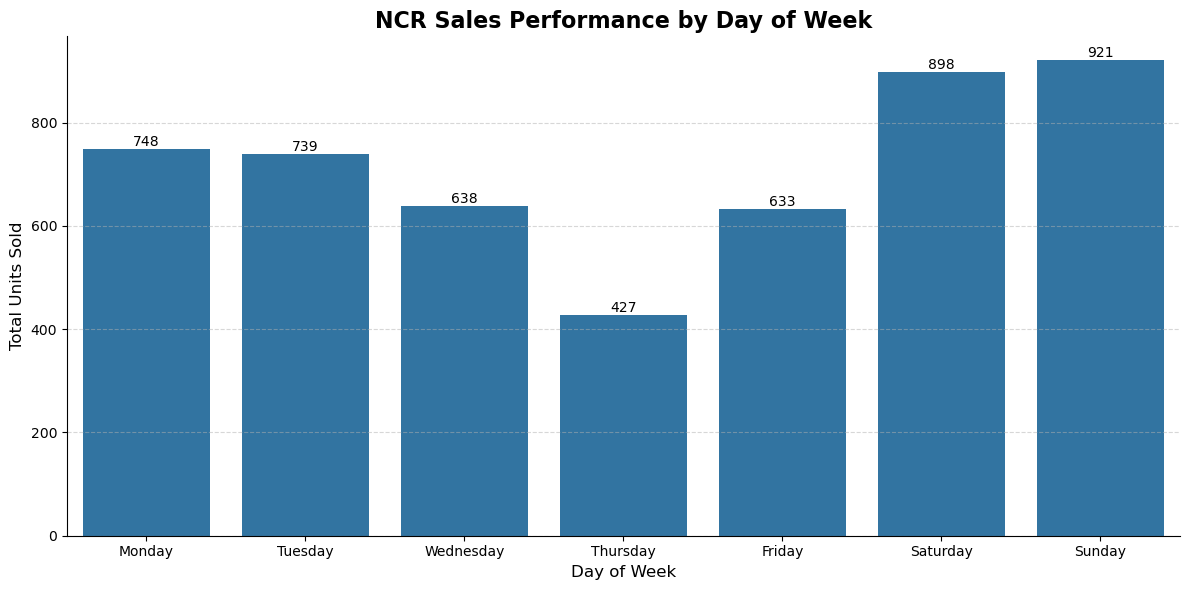

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure correct weekday order
day_order = [
    "Monday","Tuesday","Wednesday",
    "Thursday","Friday","Saturday","Sunday"
]

ncr_day_analysis = ncr_day_analysis.sort_values(
    by="DAY_NAME",
    key=lambda x: pd.Categorical(x, categories=day_order, ordered=True)
)

plt.figure(figsize=(12,6))

ax = sns.barplot(
    data=ncr_day_analysis,
    x="DAY_NAME",
    y="TOTAL_UNITS_SOLD"
)

# Add values on bars
for container in ax.containers:
    ax.bar_label(container, fmt='%d', fontsize=10)

# Chart formatting
plt.title("NCR Sales Performance by Day of Week", fontsize=16, weight='bold')
plt.xlabel("Day of Week", fontsize=12)
plt.ylabel("Total Units Sold", fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.5)

sns.despine()

plt.tight_layout()

plt.show()

# Product Demand Table (Units Sold + Revenue)

In [19]:
ncr_product_demand = ncr_df.groupby("PRODUCT_NAME").agg(
    TOTAL_UNITS_SOLD=("UNITS_SOLD","sum"),
    TOTAL_REVENUE=("GMV","sum")
).reset_index()

ncr_product_demand = ncr_product_demand.sort_values(
    by="TOTAL_UNITS_SOLD",
    ascending=False
)

ncr_product_demand.head(20)

,PRODUCT_NAME,TOTAL_UNITS_SOLD,TOTAL_REVENUE
6,nanihaal imli ( seedless),1492,97465
5,nanihaal hari elaichi,547,116420
14,nanihaal sabut methi dana,532,21280
0,nanihaal ajwain,337,23258
15,nanihaal safed til,324,19440
9,nanihaal kalonji,266,19212
11,nanihaal moti elaichi,236,57780
1,nanihaal black kaali rai,217,10416
12,nanihaal moti saunf,188,19740
7,nanihaal jeera,138,23460


# Top 10 Products Sold in NCR

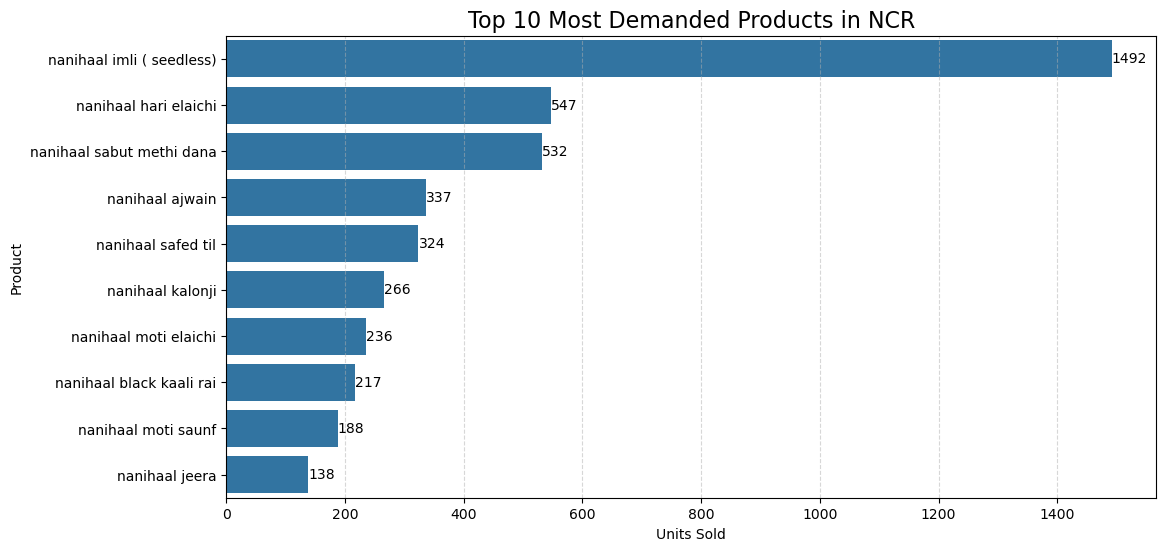

In [20]:
top_products = ncr_product_demand.head(10)

plt.figure(figsize=(12,6))

ax = sns.barplot(
    data=top_products,
    x="TOTAL_UNITS_SOLD",
    y="PRODUCT_NAME"
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Top 10 Most Demanded Products in NCR", fontsize=16)
plt.xlabel("Units Sold")
plt.ylabel("Product")

plt.grid(axis="x", linestyle="--", alpha=0.5)

plt.show()

# Product Revenue Contribution

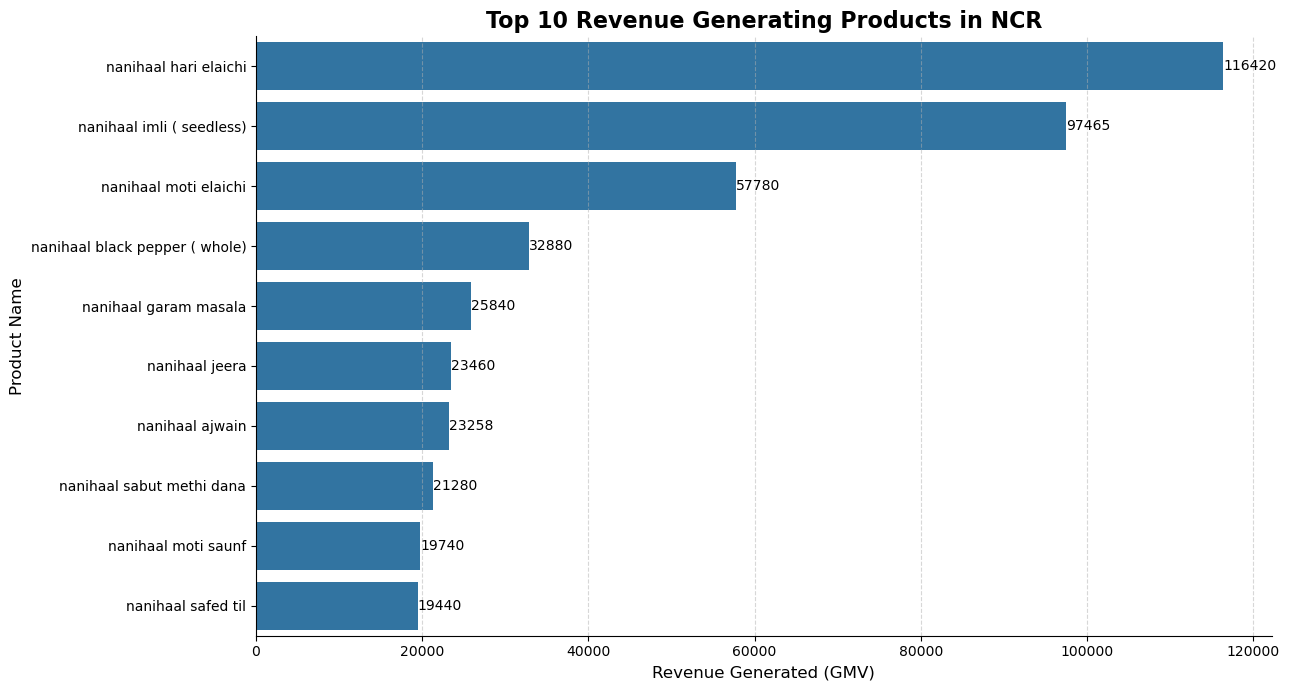

In [22]:
# Sort products by revenue
top_revenue_products = ncr_product_demand.sort_values(
    by="TOTAL_REVENUE",
    ascending=False
).head(10)

plt.figure(figsize=(13,7))

ax = sns.barplot(
    data=top_revenue_products,
    x="TOTAL_REVENUE",
    y="PRODUCT_NAME"
)

# Add revenue labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f')

# Improve formatting
plt.title("Top 10 Revenue Generating Products in NCR", fontsize=16, weight="bold")
plt.xlabel("Revenue Generated (GMV)", fontsize=12)
plt.ylabel("Product Name", fontsize=12)

plt.grid(axis="x", linestyle="--", alpha=0.5)

sns.despine()

plt.tight_layout()

plt.show()

In [23]:
top_revenue_products["REVENUE_PERCENT"] = (
    top_revenue_products["TOTAL_REVENUE"] /
    ncr_product_demand["TOTAL_REVENUE"].sum()
) * 100

top_revenue_products

,PRODUCT_NAME,TOTAL_UNITS_SOLD,TOTAL_REVENUE,REVENUE_PERCENT
5,nanihaal hari elaichi,547,116420,23.288704
6,nanihaal imli ( seedless),1492,97465,19.496938
11,nanihaal moti elaichi,236,57780,11.558335
2,nanihaal black pepper ( whole),137,32880,6.577329
4,nanihaal garam masala,136,25840,5.169044
7,nanihaal jeera,138,23460,4.692948
0,nanihaal ajwain,337,23258,4.652540
14,nanihaal sabut methi dana,532,21280,4.256860
12,nanihaal moti saunf,188,19740,3.948798
15,nanihaal safed til,324,19440,3.888786


In [25]:
area_summary = df.groupby("AREA_NAME").agg(
    TOTAL_UNITS_SOLD=("UNITS_SOLD","sum"),
    TOTAL_REVENUE=("GMV","sum")
).reset_index()

# Calculate total revenue
total_revenue = area_summary["TOTAL_REVENUE"].sum()

# Calculate revenue percentage
area_summary["REVENUE_PERCENTAGE"] = (
    area_summary["TOTAL_REVENUE"] / total_revenue
) * 100

area_summary["REVENUE_PERCENTAGE"] = area_summary["REVENUE_PERCENTAGE"].round(2)

# Sort by revenue
area_summary = area_summary.sort_values(
    by="TOTAL_REVENUE",
    ascending=False
)

area_summary

,AREA_NAME,TOTAL_UNITS_SOLD,TOTAL_REVENUE,REVENUE_PERCENTAGE
50,crossing republic,440,43048,5.12
96,jalvayu towers,389,37890,4.51
203,sector 50,290,28268,3.36
189,raj nagar,287,28156,3.35
161,noida expressway,274,27343,3.25
...,...,...,...,...
69,ghatkopar vikhroli,2,60,0.01
143,matunga wadala,2,60,0.01
17,bbd,1,30,0.00
117,kothrud,1,30,0.00


In [26]:
pd.set_option('display.max_rows', None)

area_summary

,AREA_NAME,TOTAL_UNITS_SOLD,TOTAL_REVENUE,REVENUE_PERCENTAGE
50,crossing republic,440,43048,5.12
96,jalvayu towers,389,37890,4.51
203,sector 50,290,28268,3.36
189,raj nagar,287,28156,3.35
161,noida expressway,274,27343,3.25
169,old gurgaon (zone 6),250,24097,2.87
93,indirapuram,225,23789,2.83
214,sohna road,244,22944,2.73
158,new sohna road,223,21282,2.53
56,dlf phase 4,192,18750,2.23
